In [52]:
import pandas as pd
import h5py
import json
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pickle

In [53]:
experiment_path = (
    "/Users/clairenastaskin/data/2025-03-13/task_joystick_run-01/34mm_46mm/"
)
probe_event_stream = os.path.join(experiment_path, "streams/probe_events_sub.pkl")
task_event_stream = os.path.join(experiment_path, "streams/task_events_sub.pkl")
power_doppler_frame_course_path = os.path.join(
    experiment_path, "timecourse_zscore_7-9_coord_18-32-30.txt"
)

with open(probe_event_stream, "rb") as f:
    probe_events = pickle.load(f)


with open(task_event_stream, "rb") as f:
    task_event = pickle.load(f)
print(task_event)

power_doppler_frame_course = pd.read_csv(
    power_doppler_frame_course_path, sep="\t", header=None
)

          trial_type       onset   duration
0   connect_the_dots   15.051894  17.293336
1   connect_the_dots   49.344642  11.892538
2   connect_the_dots   73.274838  19.644271
3   connect_the_dots  110.598908  14.945971
4   connect_the_dots  144.223879  14.143883
5   connect_the_dots  171.553939  12.709889
6   connect_the_dots  203.855747  11.732826
7   connect_the_dots  234.324767  10.953193
8   connect_the_dots  263.603696  17.455848
9   connect_the_dots  297.322115  18.568374
10  connect_the_dots  328.550802  14.652429
11  connect_the_dots  353.475044  20.149749
12  connect_the_dots  387.358061  19.033944
13  connect_the_dots  425.661862  15.223073
14  connect_the_dots  460.562385  16.461164
15  connect_the_dots  496.394530  10.797924
16  connect_the_dots  521.681811  16.977077
17  connect_the_dots  556.387196  11.009662


In [54]:
print(probe_events.shape)

(202, 4)


In [55]:
power_doppler_time_course = pd.DataFrame(
    {
        "timestamp": probe_events["time_stamp"].values,
        "power_doppler_value": power_doppler_frame_course.iloc[:, 0].values,
    }
)

Text(0, 0.5, 'Time between frames (s)')

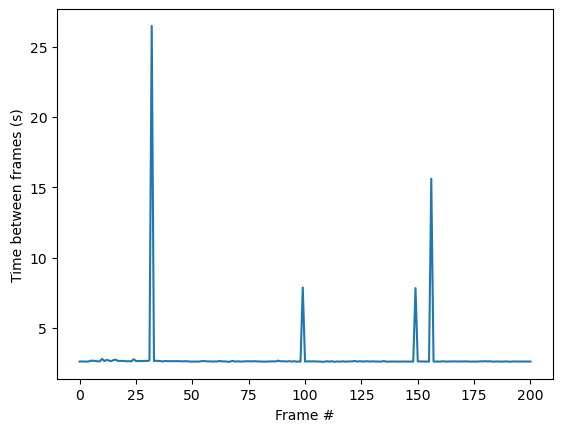

In [56]:
np.diff(power_doppler_time_course.timestamp)
plt.figure()
plt.plot(np.diff(power_doppler_time_course.timestamp))
plt.xlabel("Frame #", fontsize=10)
plt.ylabel("Time between frames (s)", fontsize=10)

In [57]:
print(task_event)

          trial_type       onset   duration
0   connect_the_dots   15.051894  17.293336
1   connect_the_dots   49.344642  11.892538
2   connect_the_dots   73.274838  19.644271
3   connect_the_dots  110.598908  14.945971
4   connect_the_dots  144.223879  14.143883
5   connect_the_dots  171.553939  12.709889
6   connect_the_dots  203.855747  11.732826
7   connect_the_dots  234.324767  10.953193
8   connect_the_dots  263.603696  17.455848
9   connect_the_dots  297.322115  18.568374
10  connect_the_dots  328.550802  14.652429
11  connect_the_dots  353.475044  20.149749
12  connect_the_dots  387.358061  19.033944
13  connect_the_dots  425.661862  15.223073
14  connect_the_dots  460.562385  16.461164
15  connect_the_dots  496.394530  10.797924
16  connect_the_dots  521.681811  16.977077
17  connect_the_dots  556.387196  11.009662


In [58]:
task_list_type = task_event.trial_type.unique()
print(task_list_type)

['connect_the_dots']


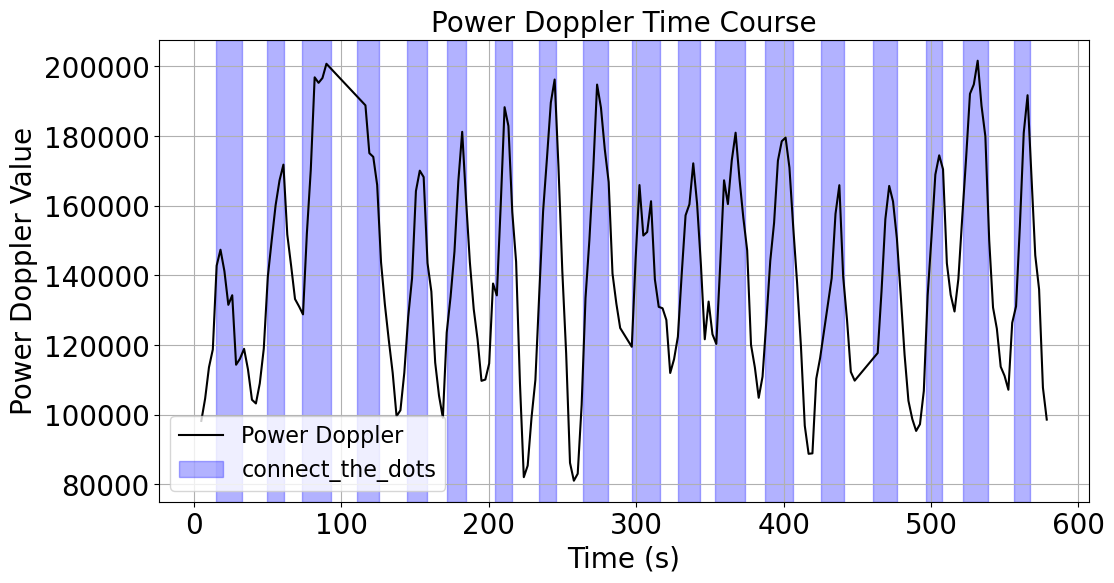

In [59]:
plt.figure(figsize=(12, 6))
plt.plot(
    power_doppler_time_course.timestamp,
    power_doppler_time_course.power_doppler_value,
    color="black",
    label="Power Doppler"
)

task_colors = ['blue','purple', 'gray', 'lightgreen']

# Add colored rectangles for stimulus periods
for task_index in range(len(task_list_type)):
    task = task_list_type[task_index]
    task_events_timing = pd.DataFrame()
    task_events_timing["Event"] = ["start", "stop"] * len(
        task_event[task_event["trial_type"] == task]
    )
    task_events_timing["Timestamp"] = [
        onset
        for onset, duration in zip(
            task_event[task_event["trial_type"] == task]["onset"],
            task_event[task_event["trial_type"] == task]["duration"],
        )
        for _ in range(2)
    ]
    task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += (
        task_event[task_event["trial_type"] == task]["duration"].values.repeat(1)
    )
    task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
    start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"]
    stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"]
    for start, stop in zip(start_times, stop_times):
        plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if start == start_times.iloc[0] else "")

plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Power Doppler Value", fontsize=20)
plt.title("Power Doppler Time Course", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()

In [60]:
import scipy.io as sio

# Load the eigenvectors spatial data
eigen_vectors_spatial = sio.loadmat(
    "/Users/clairenastaskin/data/2025-02-10/Forest001_ses-20250210_task-wrist+fingers_run-01/eigen_vectors_spatial.mat"
)

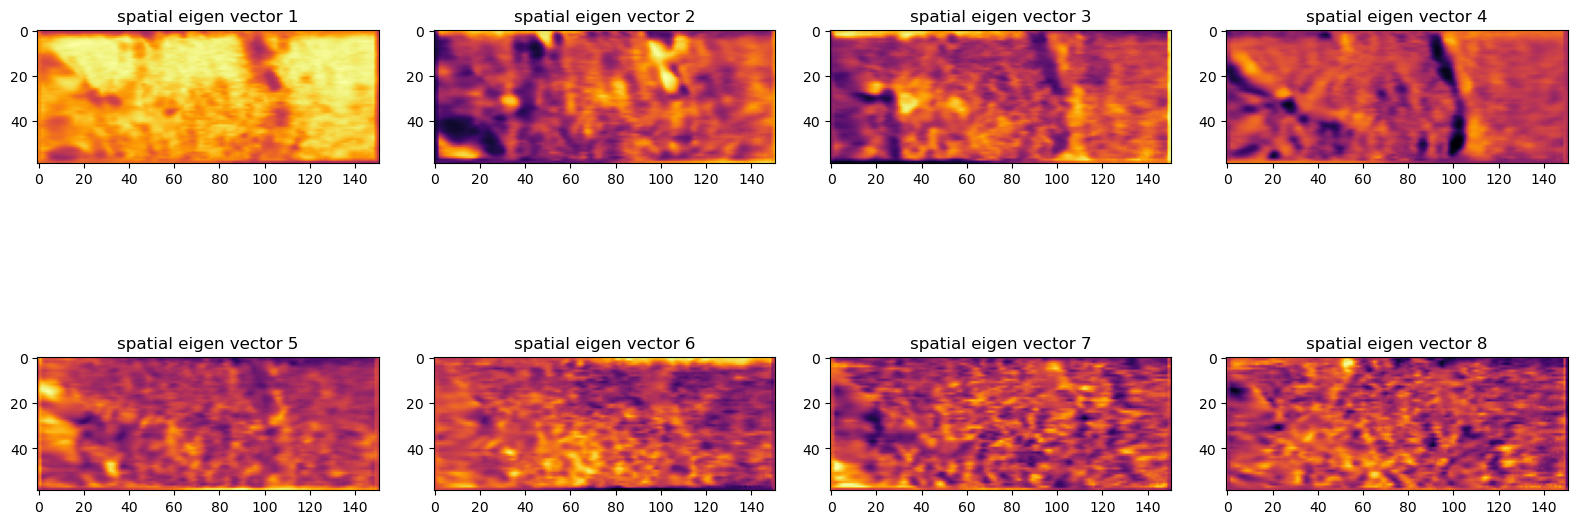

In [61]:
# Create a figure with 8 subplots arranged in 2 rows and 4 columns
plt.figure(figsize=(16, 8))

# Get the data array and reshape if needed
eigen_data = eigen_vectors_spatial["eigen_vectors_spatial"]
tmp = eigen_data.flatten()

# Plot each eigenvector
for i in range(8):
    plt.subplot(2, 4, i + 1)
    eig_2_plot = np.squeeze(eigen_data[:, 35, :, i])
    plt.imshow(np.rot90(eig_2_plot, k=3), cmap="inferno")
    plt.clim(-np.max(np.abs(eig_2_plot)), np.max(np.abs(eig_2_plot)))
    plt.title(f"spatial eigen vector {i + 1}")

plt.tight_layout()
plt.show()